In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer
cancer=load_breast_cancer()

In [3]:
X=pd.DataFrame(cancer.data,columns=cancer.feature_names)
Y=cancer.target

In [21]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [22]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
rfc=RandomForestClassifier()
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=1,stratify=Y)
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [5]:
y_pred_test=rfc.predict(X_test)
y_pred_train=rfc.predict(X_train)
print("accuracy score of Train: ",accuracy_score(y_train,y_pred_train))
print("accuracy score of Test: ",accuracy_score(y_test,y_pred_test))

accuracy score of Train:  1.0
accuracy score of Test:  0.956140350877193


### we can accept the 100% so we need to change the parameters

## n_estimator: number of decision trees used

In [67]:
rfc=RandomForestClassifier(n_estimators=200)
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=1,stratify=Y)
rfc.fit(X_train,y_train)
y_pred_test=rfc.predict(X_test)
y_pred_train=rfc.predict(X_train)
print("accuracy score of Train: ",accuracy_score(y_train,y_pred_train))
print("accuracy score of Test: ",accuracy_score(y_test,y_pred_test))

accuracy score of Train:  1.0
accuracy score of Test:  0.9649122807017544


In [68]:
rfc=RandomForestClassifier(n_estimators=250)
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=1,stratify=Y)
rfc.fit(X_train,y_train)
y_pred_test=rfc.predict(X_test)
y_pred_train=rfc.predict(X_train)
print("accuracy score of Train: ",accuracy_score(y_train,y_pred_train))
print("accuracy score of Test: ",accuracy_score(y_test,y_pred_test))

accuracy score of Train:  1.0
accuracy score of Test:  0.9649122807017544


### Entropy: Degree of Randomness

In [69]:
rfc=RandomForestClassifier(n_estimators=150,criterion='entropy')
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=1,stratify=Y)
rfc.fit(X_train,y_train)
y_pred_test=rfc.predict(X_test)
y_pred_train=rfc.predict(X_train)
print("accuracy score of Train: ",accuracy_score(y_train,y_pred_train))
print("accuracy score of Test: ",accuracy_score(y_test,y_pred_test))

accuracy score of Train:  1.0
accuracy score of Test:  0.9649122807017544


### max_depht: Depth of the Tree

In [52]:
rfc=RandomForestClassifier(n_estimators=150,max_depth=2)
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=1,stratify=Y)
rfc.fit(X_train,y_train)
y_pred_test=rfc.predict(X_test)
y_pred_train=rfc.predict(X_train)
print("accuracy score of Train: ",accuracy_score(y_train,y_pred_train))
print("accuracy score of Test: ",accuracy_score(y_test,y_pred_test))

accuracy score of Train:  0.9648351648351648
accuracy score of Train:  0.9385964912280702


In [70]:
rfc=RandomForestClassifier(n_estimators=150,max_depth=5,min_samples_leaf=20,min_samples_split=2)
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=1,stratify=Y)
rfc.fit(X_train,y_train)
y_pred_test=rfc.predict(X_test)
y_pred_train=rfc.predict(X_train)
print("accuracy score of Train: ",accuracy_score(y_train,y_pred_train))
print("accuracy score of Test: ",accuracy_score(y_test,y_pred_test))

accuracy score of Train:  0.9604395604395605
accuracy score of Test:  0.9385964912280702


### You can also use the for loop to change the parameters

In [71]:
values=[10,100,150,5,200,50]
for i in values:
    rfc=RandomForestClassifier(n_estimators=i,max_depth=i,min_samples_leaf=20,min_samples_split=2)
    X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,random_state=1,stratify=Y)
    rfc.fit(X_train,y_train)
    y_pred_test=rfc.predict(X_test)
    y_pred_train=rfc.predict(X_train)
    print(i,"  accuracy score of Train: ",accuracy_score(y_train,y_pred_train))
    print(i,"  accuracy score of Test: ",accuracy_score(y_test,y_pred_test))

10   accuracy score of Train:  0.9604395604395605
10   accuracy score of Test:  0.9473684210526315
100   accuracy score of Train:  0.9560439560439561
100   accuracy score of Test:  0.9473684210526315
150   accuracy score of Train:  0.9582417582417583
150   accuracy score of Test:  0.9385964912280702
5   accuracy score of Train:  0.9560439560439561
5   accuracy score of Test:  0.9298245614035088
200   accuracy score of Train:  0.9560439560439561
200   accuracy score of Test:  0.9385964912280702
50   accuracy score of Train:  0.9604395604395605
50   accuracy score of Test:  0.9385964912280702


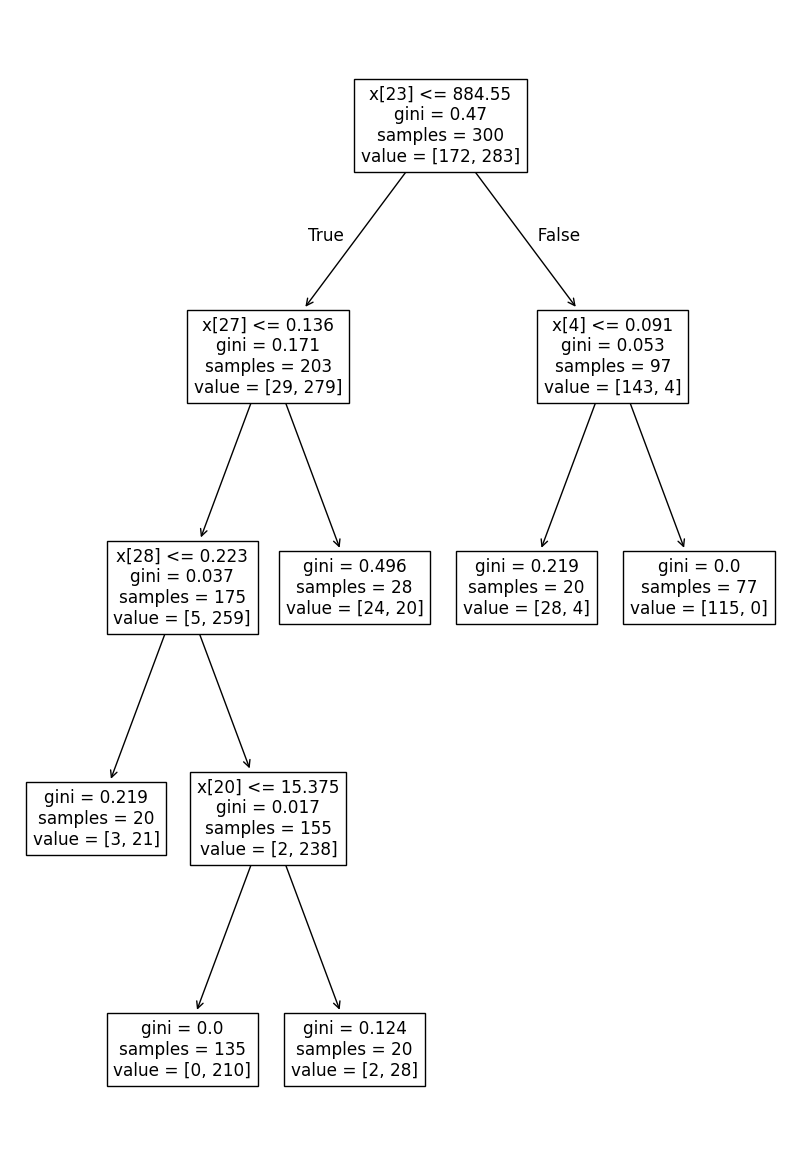

In [78]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,15))
plot_tree(rfc[1])
plt.show()

# Feature importance

In [94]:
features=pd.DataFrame(rfc.feature_importances_,index=X.columns)
features.sort_values(by=0,ascending=False)

,0
worst radius,0.148723
worst perimeter,0.146154
worst area,0.140298
mean concave points,0.139776
worst concave points,0.131937
worst concavity,0.063845
mean radius,0.047585
mean perimeter,0.043908
area error,0.032060
mean concavity,0.030371


### now u can do pruning here as well

## Cross validation

In [8]:
from sklearn.model_selection import cross_val_score
cross=cross_val_score(rfc,X_train,y_train)
cross.mean()

np.float64(0.9604395604395604)